# Gráficas de EDA, experimentación y holdout

Visualización de los CSV de `outputs/eda/`, `outputs/experimentacion/` y de las métricas finales en `outputs/modelo_final/`. Los periodos son relativos al inicio de IEEE-CIS, no meses calendario. EDA y experimentación usan datos anteriores al holdout; la última sección muestra su evaluación retrospectiva.


In [36]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_curve

outputs = (
    Path("outputs")
    if Path("outputs/eda/monthly_eda.csv").exists()
    else Path("08_entrega_final_codigo/outputs")
)
assert (outputs / "eda/monthly_eda.csv").exists() and (
    outputs / "experimentacion/inner_cv.csv"
).exists(), "No se encontraron los CSV"
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)
BLUE, GREEN, ORANGE, RED = "#175cd3", "#039855", "#dc6803", "#b42318"
eda = pd.read_csv(outputs / "eda/monthly_eda.csv")
missing = pd.read_csv(outputs / "eda/monthly_missingness.csv")
full_missing = pd.read_csv(outputs / "eda/monthly_missingness_all.csv")
shift = pd.read_csv(outputs / "eda/monthly_shift.csv")
cv = pd.read_csv(outputs / "experimentacion/inner_cv.csv")
weekly = pd.read_csv(outputs / "experimentacion/inner_weekly.csv")
fits = pd.read_csv(outputs / "experimentacion/fit_log.csv")
print("EDA:", len(eda), "periodos; experimentación:", len(cv), "evaluaciones internas")

EDA: 6 periodos; experimentación: 28 evaluaciones internas


## EDA temporal

Las tasas usan solo entrenamiento y validación; el holdout se excluyó al generar estos CSV. El último periodo puede quedar incompleto por el corte de validación, así que su volumen no es directamente comparable con los anteriores.


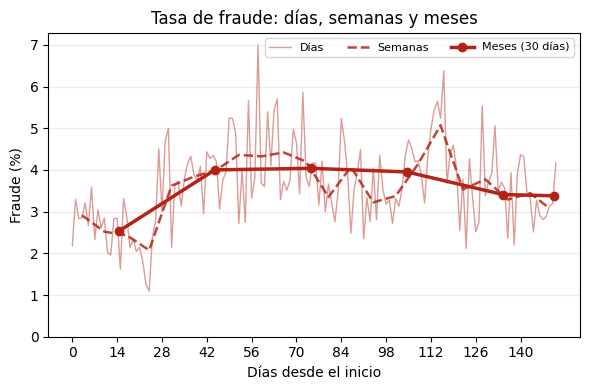

In [2]:
temporal = pd.read_csv(outputs / "eda/temporal_eda.csv")
series_eda = []
for label, span, alpha, linewidth, linestyle, marker in [
    ("Días", 1, 0.45, 1, "-", None),
    ("Semanas", 7, 0.85, 1.8, "--", None),
    ("Meses (30 días)", 30, 1, 2.5, "-", "o"),
]:
    grouped = temporal.loc[temporal.window_days == span]
    series_eda.append(
        (label, grouped.mid_day, grouped, alpha, linewidth, linestyle, marker)
    )

fig, ax = plt.subplots(figsize=(6, 4))
for label, mid_day, grouped, alpha, linewidth, linestyle, marker in series_eda:
    ax.plot(
        mid_day,
        100 * grouped.fraud_rate,
        label=label,
        color=RED,
        alpha=alpha,
        linewidth=linewidth,
        linestyle=linestyle,
        marker=marker,
    )
ax.set(
    xlabel="Días desde el inicio",
    ylabel="Fraude (%)",
    title="Tasa de fraude: días, semanas y meses",
)
ax.set_xticks(np.arange(0, temporal.last_day.max() + 1, 14))
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(bottom=0)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

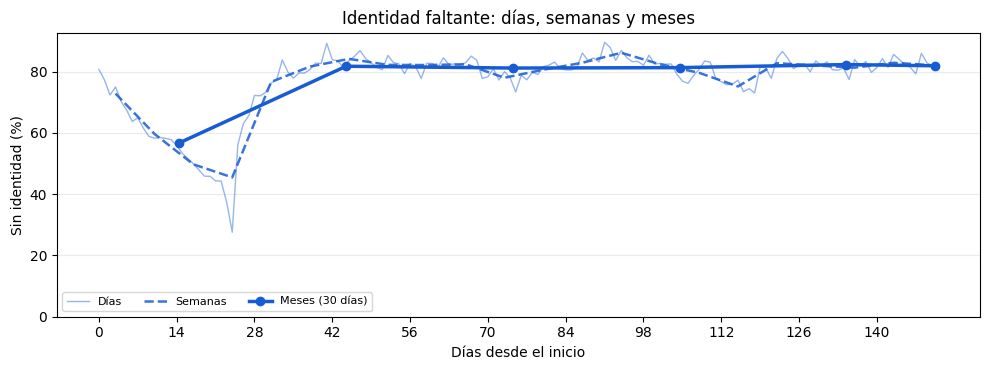

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.8))
for label, mid_day, grouped, alpha, linewidth, linestyle, marker in series_eda:
    ax.plot(
        mid_day,
        100 * grouped.identity_missing,
        label=label,
        color=BLUE,
        alpha=alpha,
        linewidth=linewidth,
        linestyle=linestyle,
        marker=marker,
    )
ax.set(
    xlabel="Días desde el inicio",
    ylabel="Sin identidad (%)",
    title="Identidad faltante: días, semanas y meses",
)
ax.set_xticks(np.arange(0, temporal.last_day.max() + 1, 14))
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(bottom=0)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()

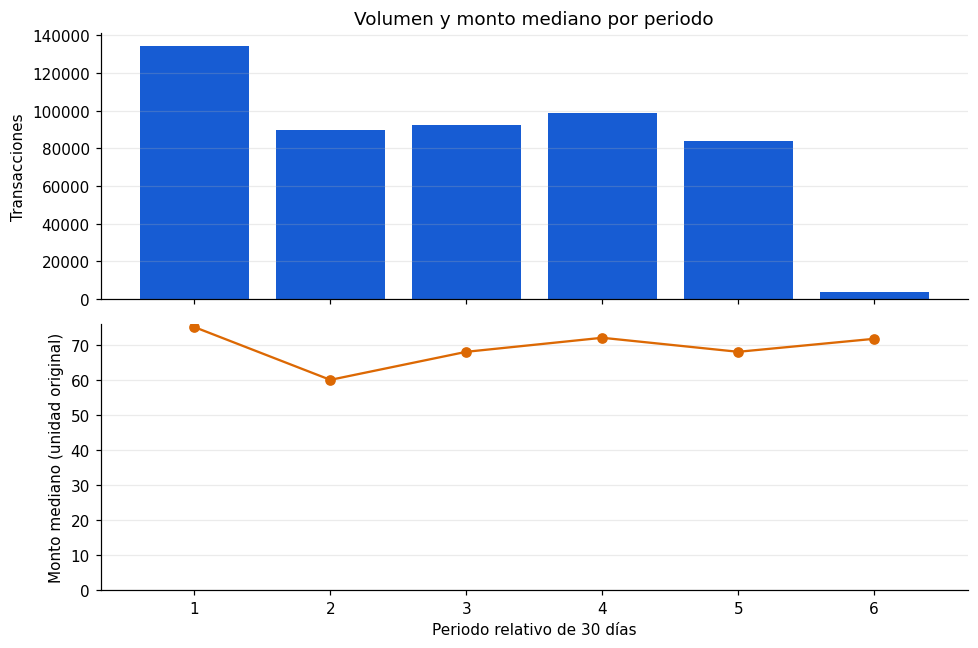

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].bar(eda.month_relative, eda.rows, color=BLUE)
axes[0].set(ylabel="Transacciones", title="Volumen y monto mediano por periodo")
axes[1].plot(eda.month_relative, eda.median_amount, marker="o", color=ORANGE)
axes[1].set(
    xlabel="Periodo relativo de 30 días", ylabel="Monto mediano (unidad original)"
)
for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(bottom=0)
axes[1].set_xticks(eda.month_relative)
fig.tight_layout()
plt.show()

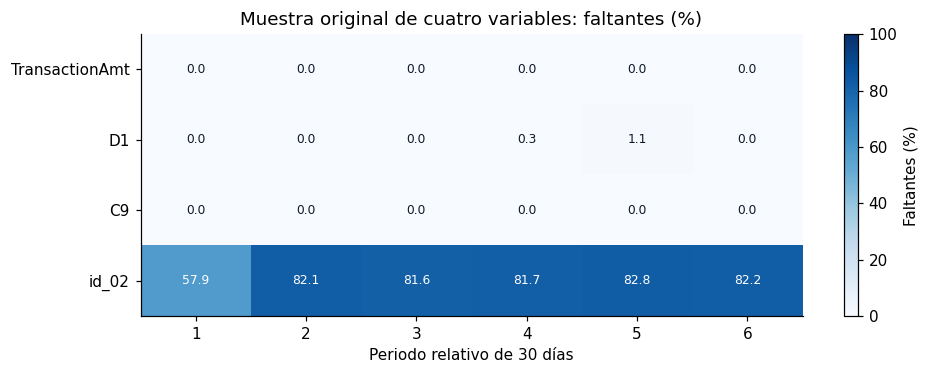

In [4]:
cols = ["TransactionAmt", "D1", "C9", "id_02"]
rates = missing.set_index("month_relative")[cols].T * 100
fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(rates, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set(
    xticks=range(len(rates.columns)),
    xticklabels=rates.columns,
    yticks=range(len(cols)),
    yticklabels=cols,
    xlabel="Periodo relativo de 30 días",
    title="Muestra original de cuatro variables: faltantes (%)",
)
for row in range(len(cols)):
    for col in range(len(rates.columns)):
        value = rates.iloc[row, col]
        ax.text(
            col,
            row,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="white" if value > 50 else "#101828",
            fontsize=8,
        )
fig.colorbar(im, ax=ax, label="Faltantes (%)")
fig.tight_layout()
plt.show()

### Todas las variables originales

La gráfica anterior reproduce la muestra de cuatro columnas del EDA inicial. El nuevo CSV calcula faltantes para **431 variables originales** (se excluyen identificador, tiempo y etiqueta). Las siguientes vistas resumen las 431 y muestran las 25 con mayor cambio temporal; el CSV conserva cada variable y periodo.


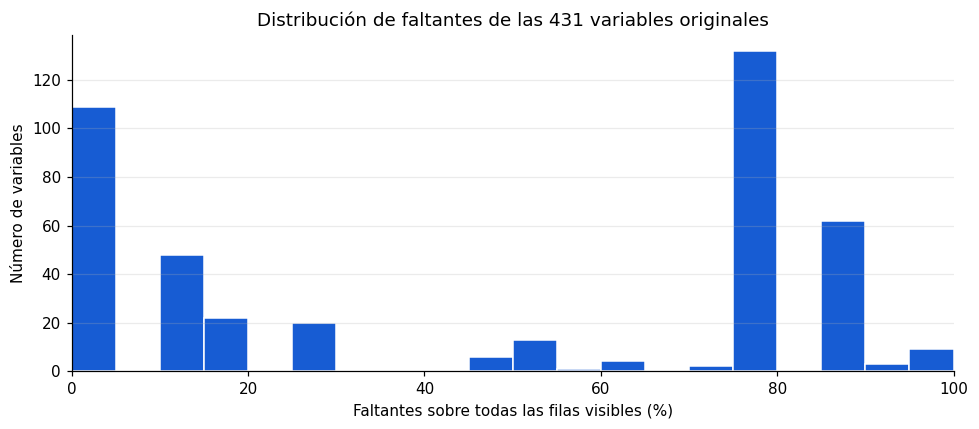

20 variables con más faltantes en promedio:


,overall_pct,change_pp
feature,,
id_24,99.2,1.0
id_25,99.1,1.0
id_08,99.1,1.0
id_07,99.1,1.0
id_21,99.1,1.0
id_26,99.1,1.0
id_27,99.1,1.0
id_23,99.1,1.0
id_22,99.1,1.0


In [5]:
profile = (
    full_missing.assign(weighted=full_missing.missing_rate * full_missing.rows)
    .groupby("feature")
    .agg(
        missing_sum=("weighted", "sum"),
        rows=("rows", "sum"),
        missing_min=("missing_rate", "min"),
        missing_max=("missing_rate", "max"),
    )
)
profile["overall_pct"] = 100 * profile.missing_sum / profile.rows
profile["change_pp"] = 100 * (profile.missing_max - profile.missing_min)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(profile.overall_pct, bins=np.arange(0, 105, 5), color=BLUE, edgecolor="white")
ax.set(
    xlabel="Faltantes sobre todas las filas visibles (%)",
    ylabel="Número de variables",
    title=f"Distribución de faltantes de las {len(profile)} variables originales",
    xlim=(0, 100),
)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()
print("20 variables con más faltantes en promedio:")
display(
    profile[["overall_pct", "change_pp"]]
    .sort_values("overall_pct", ascending=False)
    .head(20)
    .round(1)
)

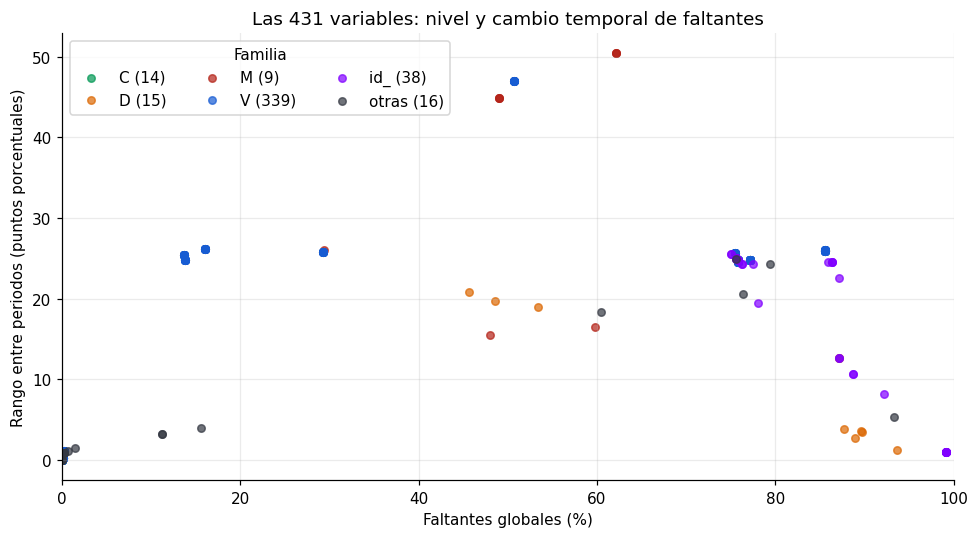

In [6]:
def family(name):
    if name.startswith("id_"):
        return "id_"
    for prefix in ("V", "D", "C", "M"):
        if name.startswith(prefix) and name[len(prefix) :].isdigit():
            return prefix
    return "otras"


profile["family"] = [family(name) for name in profile.index]
colors = {
    "V": BLUE,
    "D": ORANGE,
    "C": GREEN,
    "M": RED,
    "id_": "#8000ff",
    "otras": "#343842",
}
fig, ax = plt.subplots(figsize=(9, 5))
for group, part in profile.groupby("family"):
    ax.scatter(
        part.overall_pct,
        part.change_pp,
        s=24,
        alpha=0.7,
        color=colors[group],
        label=f"{group} ({len(part)})",
    )
ax.set(
    xlabel="Faltantes globales (%)",
    ylabel="Rango entre periodos (puntos porcentuales)",
    title="Las 431 variables: nivel y cambio temporal de faltantes",
    xlim=(0, 100),
)
ax.grid(alpha=0.25)
ax.legend(title="Familia", ncol=3)
fig.tight_layout()
plt.show()

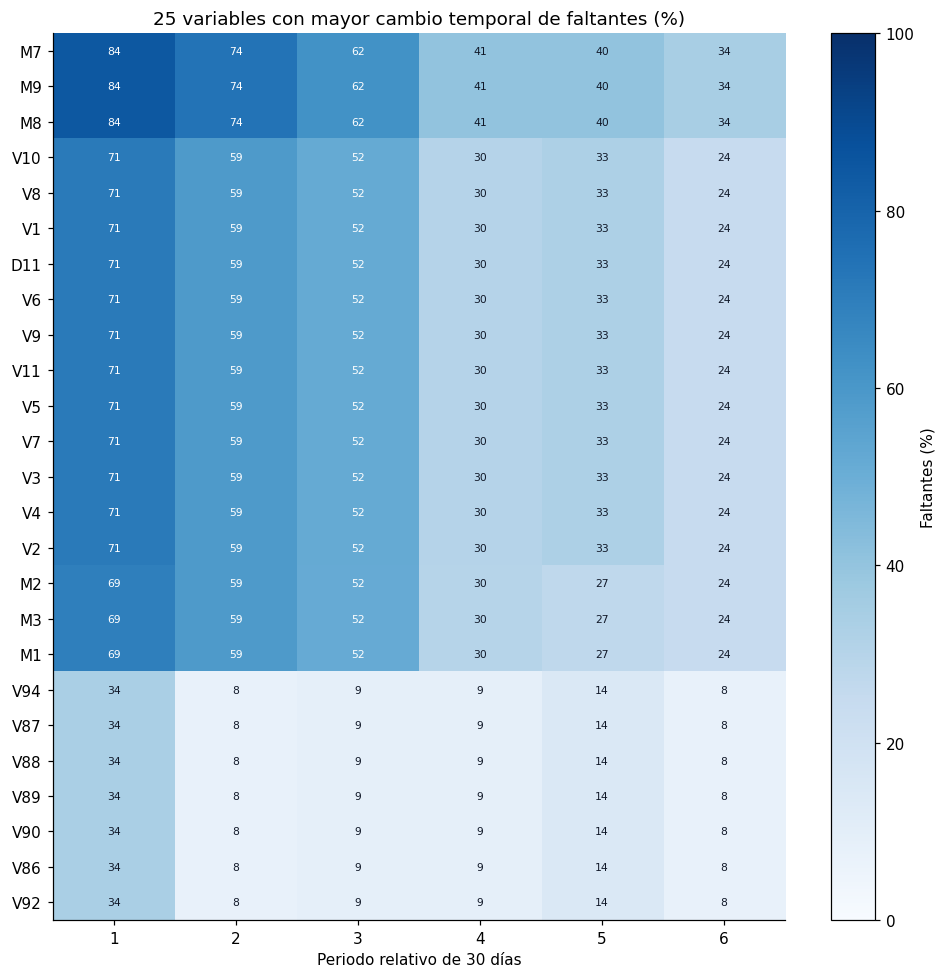

In [7]:
top = profile.sort_values("change_pp", ascending=False).head(25).index
matrix = (
    full_missing[full_missing.feature.isin(top)]
    .pivot(index="feature", columns="month_relative", values="missing_rate")
    .loc[top]
    * 100
)
fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set(
    xticks=range(len(matrix.columns)),
    xticklabels=matrix.columns,
    yticks=range(len(matrix)),
    yticklabels=matrix.index,
    xlabel="Periodo relativo de 30 días",
    title="25 variables con mayor cambio temporal de faltantes (%)",
)
for row in range(len(matrix)):
    for col in range(len(matrix.columns)):
        value = matrix.iloc[row, col]
        ax.text(
            col,
            row,
            f"{value:.0f}",
            ha="center",
            va="center",
            color="white" if value > 50 else "#101828",
            fontsize=7,
        )
fig.colorbar(im, ax=ax, label="Faltantes (%)")
fig.tight_layout()
plt.show()

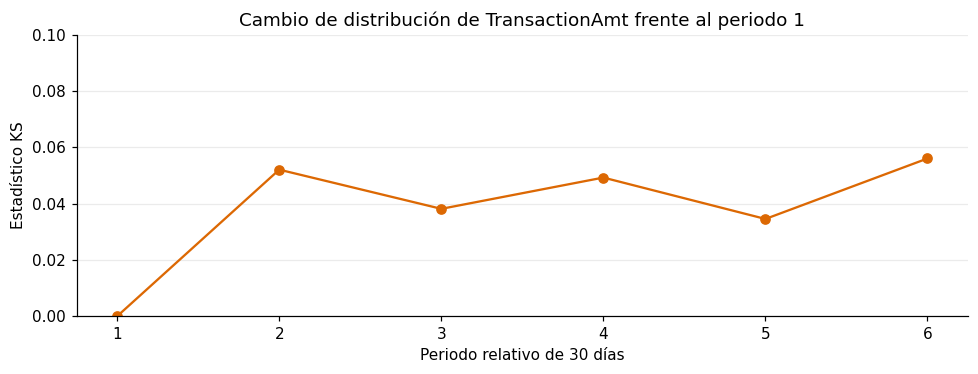

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(shift.month_relative, shift.amount_ks_vs_month1, marker="o", color=ORANGE)
ax.set(
    xlabel="Periodo relativo de 30 días",
    ylabel="Estadístico KS",
    title="Cambio de distribución de TransactionAmt frente al periodo 1",
    xticks=shift.month_relative,
)
ax.set_ylim(0, max(0.1, shift.amount_ks_vs_month1.max() * 1.2))
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## Relación con fraude de cada variable original

`feature_associations.csv` contiene una fila por cada una de las 431 variables originales, calculada solo con entrenamiento histórico (sin los últimos siete días antes de validación). Para variables numéricas se usa correlación de Pearson con `isFraud` y se conserva su signo. Para variables categóricas se usa V de Cramér, que no tiene signo. Las medidas no son directamente comparables y una asociación alta no demuestra causalidad ni ausencia de fuga.


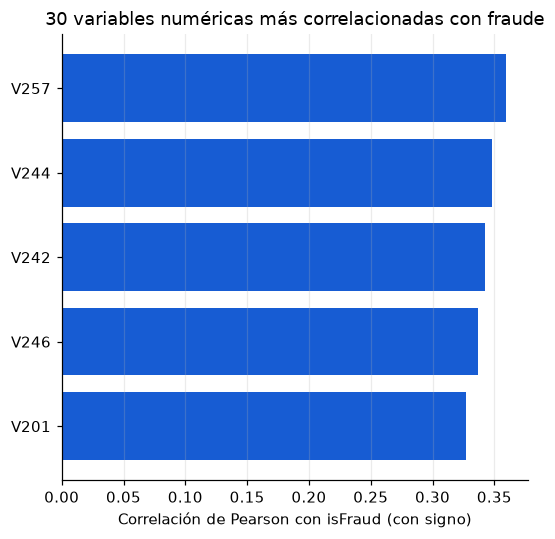

Variables originales analizadas: 431 | numéricas: 400 | categóricas: 31


In [23]:
assoc = pd.read_csv(outputs / "eda/feature_associations.csv")
numeric_assoc = assoc[
    (assoc.measure == "pearson_r") & (assoc.non_null_rows >= 1000)
].dropna(subset=["signed_correlation"])
top_corr = numeric_assoc.nlargest(5, "association").sort_values("association")
fig, ax = plt.subplots(figsize=(5, 5))
ax.barh(
    top_corr.feature,
    top_corr.signed_correlation,
    color=np.where(top_corr.signed_correlation >= 0, BLUE, ORANGE),
)
ax.axvline(0, color="#667085", linewidth=1)
ax.set(
    xlabel="Correlación de Pearson con isFraud (con signo)",
    title="30 variables numéricas más correlacionadas con fraude",
)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()
print(
    "Variables originales analizadas:",
    len(assoc),
    "| numéricas:",
    (assoc.measure == "pearson_r").sum(),
    "| categóricas:",
    (assoc.measure == "cramers_v").sum(),
)

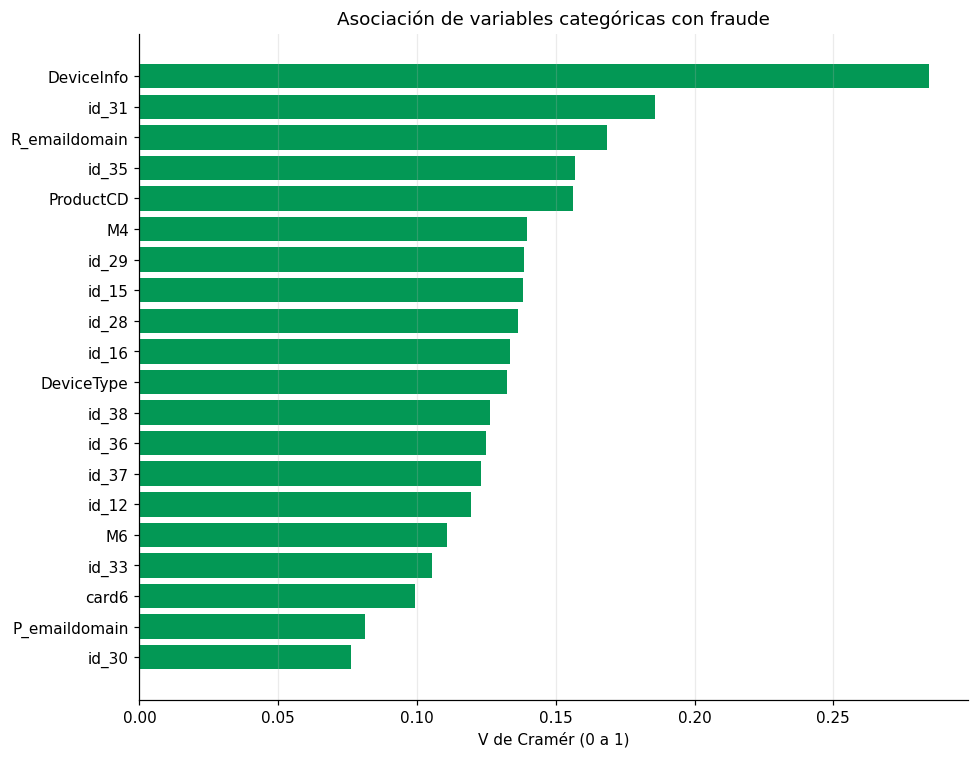

In [10]:
categorical_assoc = assoc[assoc.measure == "cramers_v"].dropna(subset=["association"])
top_cat = categorical_assoc.nlargest(20, "association").sort_values("association")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_cat.feature, top_cat.association, color=GREEN)
ax.set(
    xlabel="V de Cramér (0 a 1)", title="Asociación de variables categóricas con fraude"
)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## Importancia de variables del diagnóstico actual

Se entrenó un LightGBM independiente con el selector actual sobre datos históricos. **Ganancia** resume cuánto contribuyó una variable a las divisiones del modelo. **Permutación** mezcla una variable en 10 000 filas de validación y mide la caída de PR-AUC; solo se prueba sobre las 30 variables con mayor ganancia. Ambas son diagnósticas y no reemplazan la selección final de `02_experimentacion.ipynb` y `03_costos_escenarios.ipynb`.


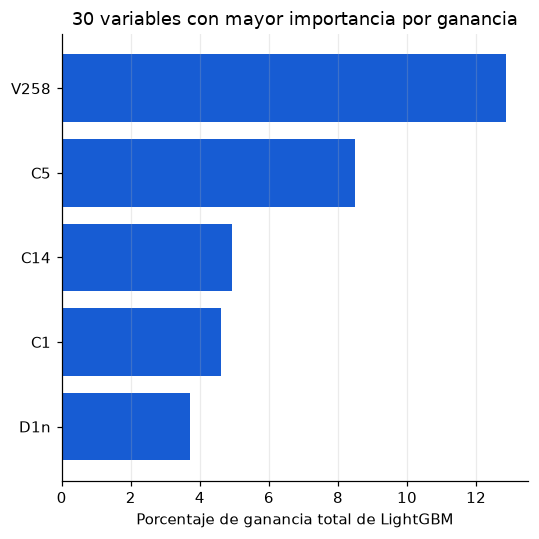

Variables del modelo diagnóstico: 190


In [24]:
gain = pd.read_csv(outputs / "eda/feature_importance_gain.csv")
permutation = pd.read_csv(outputs / "eda/feature_importance_permutation.csv")
diagnostics = json.loads(
    (outputs / "eda/feature_diagnostics.json").read_text(encoding="utf-8")
)
ranked_gain = gain.nlargest(5, "gain").sort_values("gain")
fig, ax = plt.subplots(figsize=(5, 5))
ax.barh(ranked_gain.feature, 100 * ranked_gain.gain / gain.gain.sum(), color=BLUE)
ax.set(
    xlabel="Porcentaje de ganancia total de LightGBM",
    title="30 variables con mayor importancia por ganancia",
)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()
print("Variables del modelo diagnóstico:", diagnostics["model_features"])

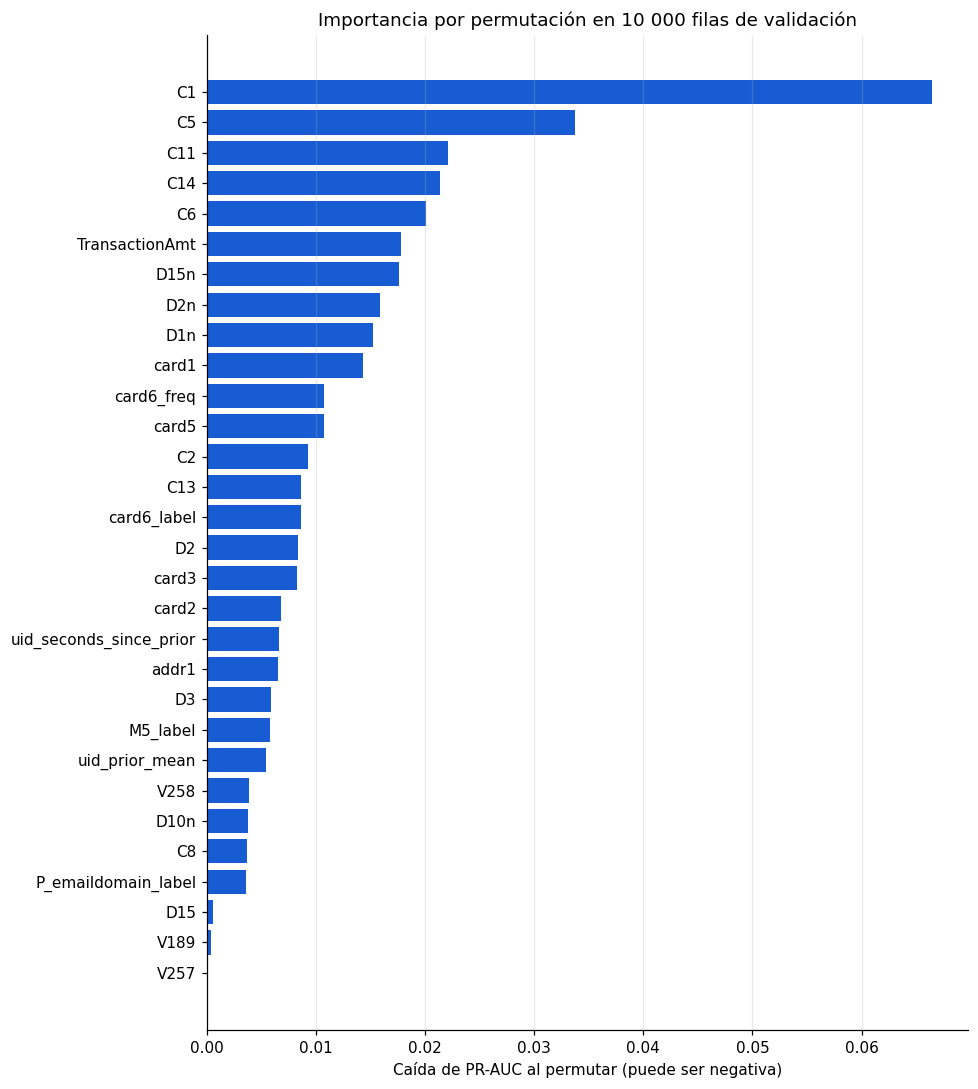

PR-AUC original en esta muestra: 0.486


In [12]:
ranked_perm = permutation.sort_values("pr_auc_drop")
fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(
    ranked_perm.feature,
    ranked_perm.pr_auc_drop,
    color=np.where(ranked_perm.pr_auc_drop >= 0, BLUE, ORANGE),
)
ax.axvline(0, color="#667085", linewidth=1)
ax.set(
    xlabel="Caída de PR-AUC al permutar (puede ser negativa)",
    title="Importancia por permutación en 10 000 filas de validación",
)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()
print("PR-AUC original en esta muestra:", round(permutation.baseline_pr_auc.iloc[0], 3))

## Estado de variables temporales y campos excluidos

Las cuatro exclusiones explícitas del modelo son `isFraud`, `TransactionID`, `TransactionDT` y `uid`. `relative_day`, `month_relative` y `period` sirven solo para el EDA. **`DT_hour` sí se genera y puede entrar al modelo actual.** `DT_week` y `DT_month_proxy` aparecen en un EDA anterior (`02_kaggle_kernels/eda/main.py`), pero no se generan en `08_entrega_final_codigo`. No existe `DR_month_proxy` en el código revisado; probablemente se quiso decir `DT_month_proxy`. Estas categorías describen el estado del código; una variable temporal no constituye fuga por definición.


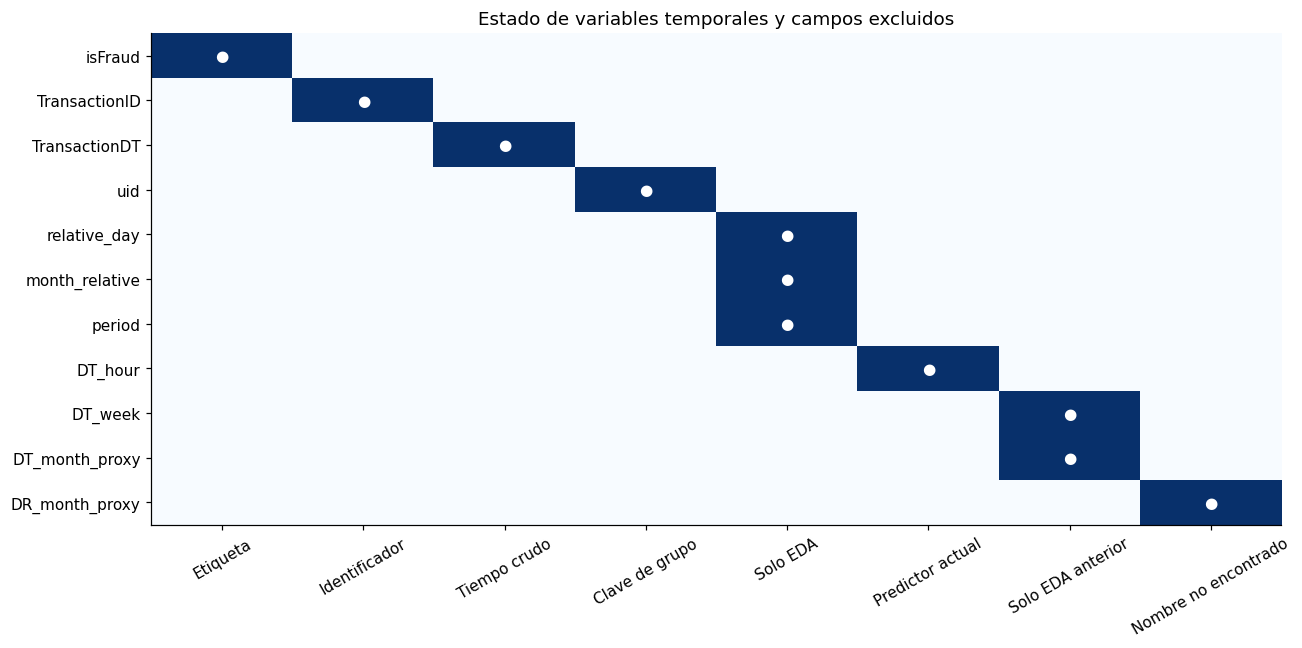

In [13]:
audit = json.loads((outputs / "eda/leakage_audit.json").read_text(encoding="utf-8"))
explicit = set(audit["excluded_from_predictors"])
current_features = set(gain.feature)
items = [
    ("isFraud", "Etiqueta", "excluido"),
    ("TransactionID", "Identificador", "excluido"),
    ("TransactionDT", "Tiempo crudo", "excluido"),
    ("uid", "Clave de grupo", "excluido"),
    ("relative_day", "Solo EDA", "no predictor"),
    ("month_relative", "Solo EDA", "no predictor"),
    ("period", "Solo EDA", "no predictor"),
    ("DT_hour", "Predictor actual", "incluido"),
    ("DT_week", "Solo EDA anterior", "no generado actual"),
    ("DT_month_proxy", "Solo EDA anterior", "no generado actual"),
    ("DR_month_proxy", "Nombre no encontrado", "no existe"),
]
assert {name for name, _, status in items if status == "excluido"} == explicit
assert "DT_hour" in current_features
assert not {"DT_week", "DT_month_proxy", "DR_month_proxy"} & current_features
reasons = [
    "Etiqueta",
    "Identificador",
    "Tiempo crudo",
    "Clave de grupo",
    "Solo EDA",
    "Predictor actual",
    "Solo EDA anterior",
    "Nombre no encontrado",
]
matrix = np.zeros((len(items), len(reasons)))
for row, (_, reason, _) in enumerate(items):
    matrix[row, reasons.index(reason)] = 1
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set(
    xticks=range(len(reasons)),
    xticklabels=reasons,
    yticks=range(len(items)),
    yticklabels=[name for name, _, _ in items],
    title="Estado de variables temporales y campos excluidos",
)
ax.tick_params(axis="x", labelrotation=30)
for row, (_, reason, _) in enumerate(items):
    ax.text(
        reasons.index(reason),
        row,
        "●",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
    )
fig.tight_layout()
plt.show()

## Validación interna de hiperparámetros

Cada configuración se entrenó en dos folds temporales. La comparación siguiente usa PR-AUC; una media alta en estos folds no equivale a menor costo operativo.


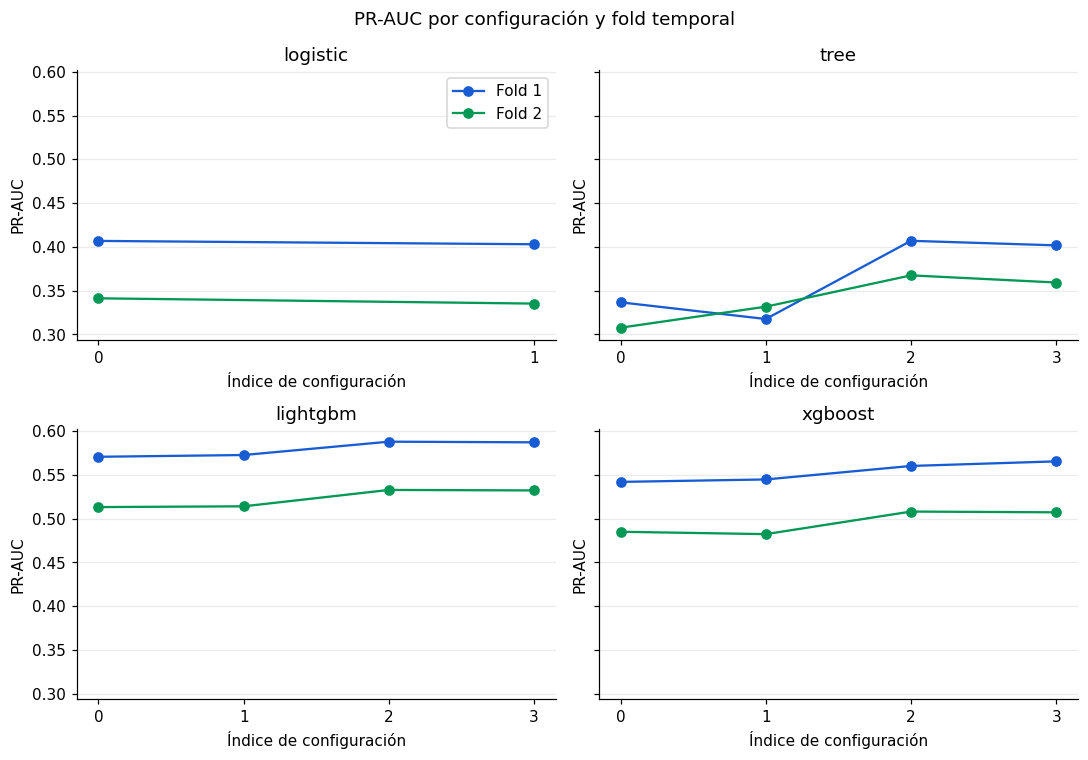

In [ ]:
models = ["logistic", "tree", "lightgbm", "xgboost"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
for ax, model in zip(axes.flat, models):
    part = cv[cv.model == model]
    for fold, color in [(1, BLUE), (2, GREEN)]:
        fold_part = part[part.fold == fold].sort_values("param_index")
        ax.plot(
            fold_part.param_index,
            fold_part.pr_auc,
            marker="o",
            color=color,
            label=f"Fold {fold}",
        )
    ax.set(
        title=model,
        xlabel="Índice de configuración",
        ylabel="PR-AUC",
        xticks=sorted(part.param_index.unique()),
    )
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].legend()
fig.suptitle("PR-AUC por configuración y fold temporal")
fig.tight_layout()
plt.show()

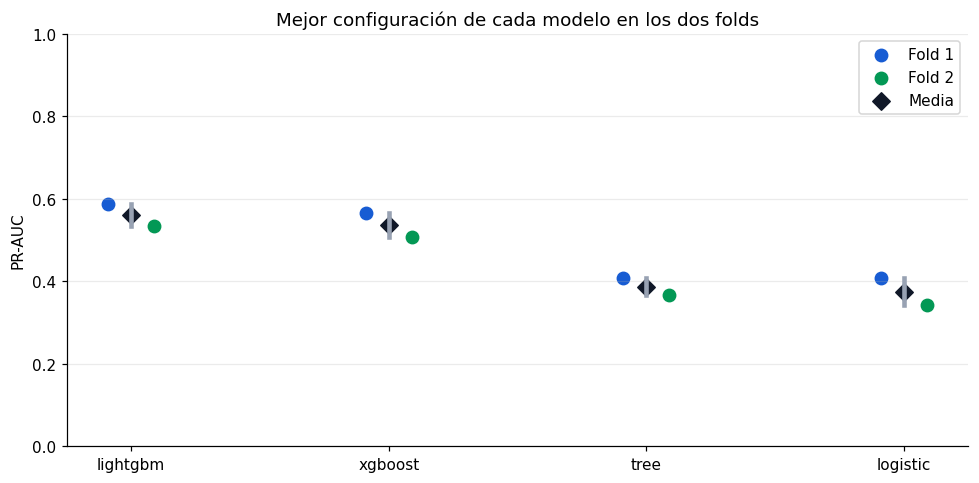

In [15]:
rank = cv.groupby(["model", "param_index"])["pr_auc"].agg(["mean", "min"]).reset_index()
best = rank.sort_values(
    ["model", "mean", "min"], ascending=[True, False, False]
).drop_duplicates("model")
chosen = cv.merge(best[["model", "param_index"]], on=["model", "param_index"])
order = best.sort_values("mean", ascending=False).model.tolist()
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, model in enumerate(order):
    scores = chosen[chosen.model == model].sort_values("fold").pr_auc.to_numpy()
    ax.plot([i, i], [scores.min(), scores.max()], color="#98a2b3", linewidth=3)
    ax.scatter(
        i - 0.09, scores[0], color=BLUE, s=65, label="Fold 1" if i == 0 else None
    )
    ax.scatter(
        i + 0.09, scores[1], color=GREEN, s=65, label="Fold 2" if i == 0 else None
    )
    ax.scatter(
        i,
        scores.mean(),
        color="#101828",
        marker="D",
        s=65,
        label="Media" if i == 0 else None,
    )
ax.set(
    xticks=range(len(order)),
    xticklabels=order,
    ylabel="PR-AUC",
    title="Mejor configuración de cada modelo en los dos folds",
    ylim=(0, 1),
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

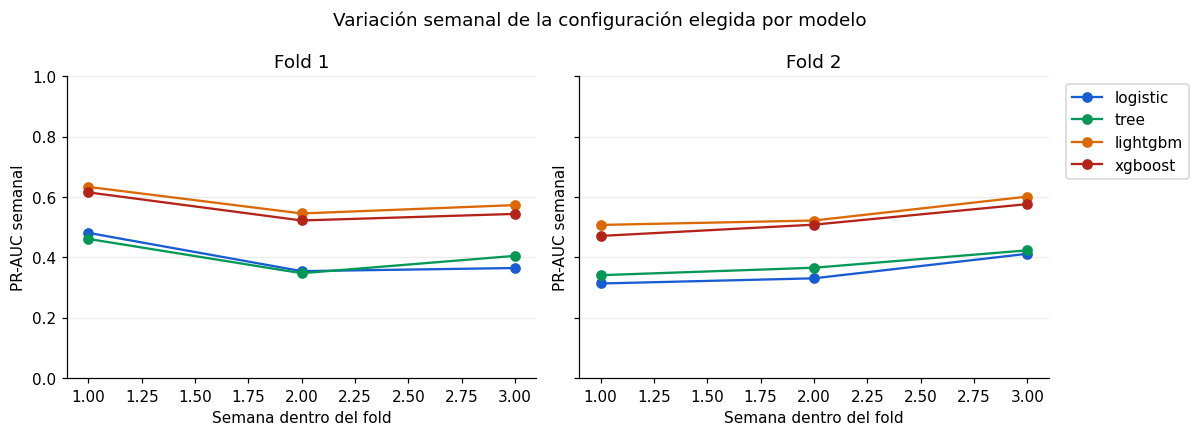

In [16]:
best_weekly = weekly.merge(best[["model", "param_index"]], on=["model", "param_index"])
colors = dict(zip(models, [BLUE, GREEN, ORANGE, RED]))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for fold, ax in enumerate(axes, 1):
    for model in models:
        part = best_weekly[
            (best_weekly.fold == fold) & (best_weekly.model == model)
        ].sort_values("week")
        ax.plot(
            part.week + 1, part.pr_auc, marker="o", color=colors[model], label=model
        )
    ax.set(
        title=f"Fold {fold}",
        xlabel="Semana dentro del fold",
        ylabel="PR-AUC semanal",
        ylim=(0, 1),
    )
    ax.grid(axis="y", alpha=0.25)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Variación semanal de la configuración elegida por modelo")
fig.tight_layout()
plt.show()

## Estrategias y predicciones de validación

El primer gráfico compara PR-AUC de los 12 candidatos sobre la validación temporal. El segundo agrupa las cinco variantes de LightGBM y XGBoost; el tercero añade el volumen de entrenamiento: suma las filas usadas en cada ajuste (una fila puede contarse varias veces), como aproximación de trabajo, **no de tiempo de cómputo**. El rendimiento no determina por sí solo la política final: esa elección se hace con escenarios de costos.


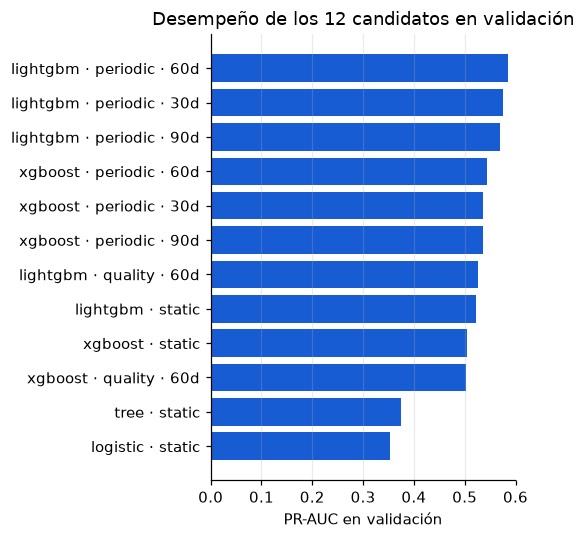

Filas por candidato: [88581.]


In [27]:
pred = pd.read_csv(
    outputs / "experimentacion/validation_predictions.csv.gz",
    usecols=["model", "strategy", "window_days", "score", "isFraud"],
    dtype={
        "model": "category",
        "strategy": "category",
        "window_days": "str",
        "score": "float32",
        "isFraud": "int8",
    },
)
summary = (
    pred.groupby(["model", "strategy", "window_days"], observed=True)
    .apply(
        lambda d: pd.Series(
            {"pr_auc": average_precision_score(d.isFraud, d.score), "rows": len(d)}
        ),
        include_groups=False,
    )
    .reset_index()
)
summary["candidate"] = (
    summary.model.astype(str)
    + " · "
    + summary.strategy.astype(str)
    + " · "
    + summary.window_days
    + "d"
)
summary.loc[summary.strategy == "static", "candidate"] = (
    summary.loc[summary.strategy == "static", "model"].astype(str) + " · static"
)
summary = summary.sort_values("pr_auc")
fig, ax = plt.subplots(figsize=(5, 5))
ax.barh(summary.candidate, summary.pr_auc, color=BLUE)
ax.set(
    xlabel="PR-AUC en validación",
    title="Desempeño de los 12 candidatos en validación",
    xlim=(0, 0.6),
)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()
print("Filas por candidato:", summary.rows.unique())

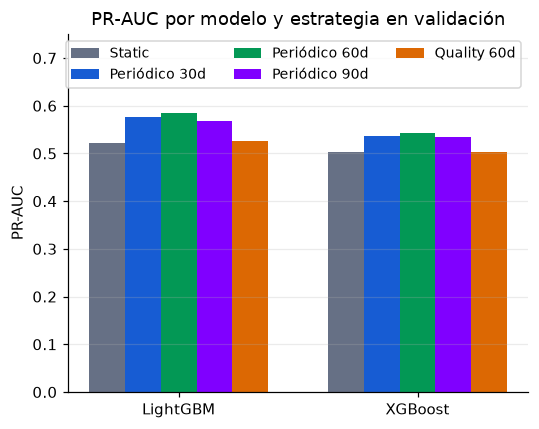

In [30]:
variants = [
    ("static", "static", "Static", "#667085"),
    ("periodic", "30", "Periódico 30d", BLUE),
    ("periodic", "60", "Periódico 60d", GREEN),
    ("periodic", "90", "Periódico 90d", "#8000ff"),
    ("quality", "60", "Quality 60d", ORANGE),
]
models = ["lightgbm", "xgboost"]
x = np.arange(len(models))
width = 0.15
fig, ax = plt.subplots(figsize=(5, 4))
for i, (strategy, days, label, color) in enumerate(variants):
    values = [
        summary.loc[
            (summary.model == model)
            & (summary.strategy == strategy)
            & (summary.window_days == days),
            "pr_auc",
        ].iloc[0]
        for model in models
    ]
    ax.bar(x + (i - 2) * width, values, width, label=label, color=color)
ax.set(
    xticks=x,
    xticklabels=["LightGBM", "XGBoost"],
    ylabel="PR-AUC",
    title="PR-AUC por modelo y estrategia en validación",
    ylim=(0, 0.75),
)
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

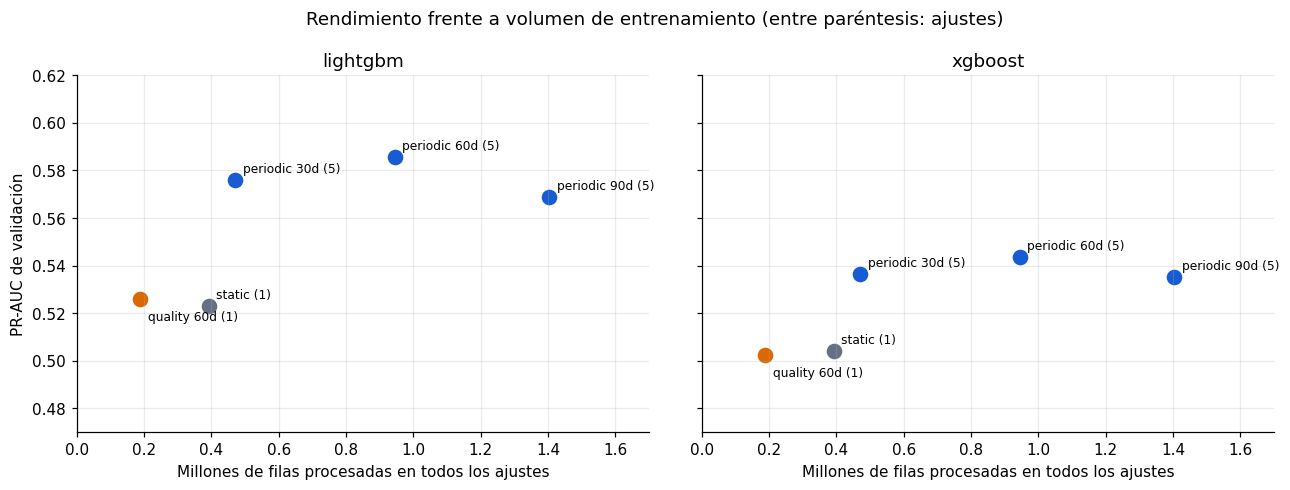

In [18]:
work = fits.copy()
work["window_days"] = work.window_days.map(
    lambda value: "static" if pd.isna(value) else str(int(value))
)
work = (
    work.groupby(["model", "strategy", "window_days"])
    .agg(fits=("train_rows", "size"), total_train_rows=("train_rows", "sum"))
    .reset_index()
)
tradeoff = summary.merge(
    work, on=["model", "strategy", "window_days"], validate="one_to_one"
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = {"static": "#667085", "quality": ORANGE, "periodic": BLUE}
for ax, model in zip(axes, ["lightgbm", "xgboost"]):
    part = tradeoff[tradeoff.model == model]
    for row in part.itertuples():
        x = row.total_train_rows / 1_000_000
        ax.scatter(x, row.pr_auc, s=85, color=colors[row.strategy])
        label = (
            row.strategy
            if row.strategy == "static"
            else f"{row.strategy} {row.window_days}d"
        )
        ax.annotate(
            f"{label} ({row.fits})",
            (x, row.pr_auc),
            xytext=(5, -14) if row.strategy == "quality" else (5, 5),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set(
        title=model,
        xlabel="Millones de filas procesadas en todos los ajustes",
        xlim=(0, 1.7),
        ylim=(0.47, 0.62),
    )
    ax.grid(alpha=0.25)
axes[0].set_ylabel("PR-AUC de validación")
fig.suptitle(
    "Rendimiento frente a volumen de entrenamiento (entre paréntesis: ajustes)"
)
fig.tight_layout()
plt.show()

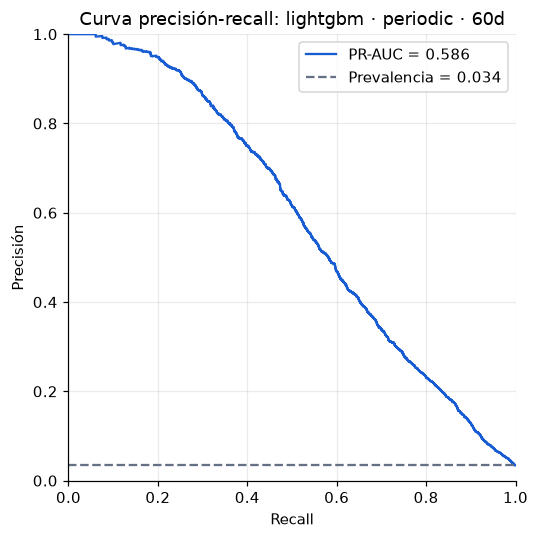

In [31]:
top = summary.iloc[-1]
selected = pred[
    (pred.model == top.model)
    & (pred.strategy == top.strategy)
    & (pred.window_days == top.window_days)
]
precision, recall, _ = precision_recall_curve(selected.isFraud, selected.score)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(recall, precision, color=BLUE, label=f"PR-AUC = {top.pr_auc:.3f}")
ax.axhline(
    selected.isFraud.mean(),
    color="#667085",
    linestyle="--",
    label=f"Prevalencia = {selected.isFraud.mean():.3f}",
)
ax.set(
    xlabel="Recall",
    ylabel="Precisión",
    xlim=(0, 1),
    ylim=(0, 1),
    title=f"Curva precisión-recall: {top.candidate}",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

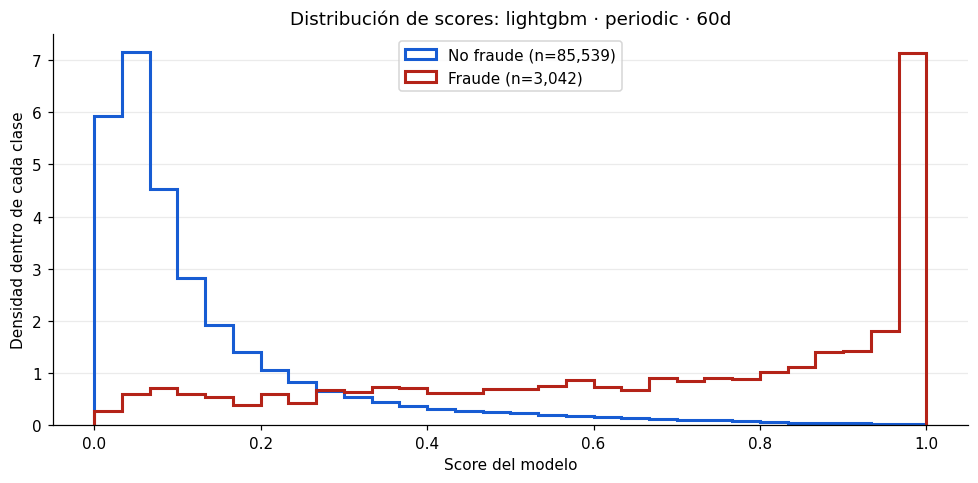

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, name, color in [(0, "No fraude", BLUE), (1, "Fraude", RED)]:
    values = selected.loc[selected.isFraud == label, "score"]
    ax.hist(
        values,
        bins=np.linspace(0, 1, 31),
        density=True,
        histtype="step",
        linewidth=2,
        color=color,
        label=f"{name} (n={len(values):,})",
    )
ax.set(
    xlabel="Score del modelo",
    ylabel="Densidad dentro de cada clase",
    title=f"Distribución de scores: {top.candidate}",
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

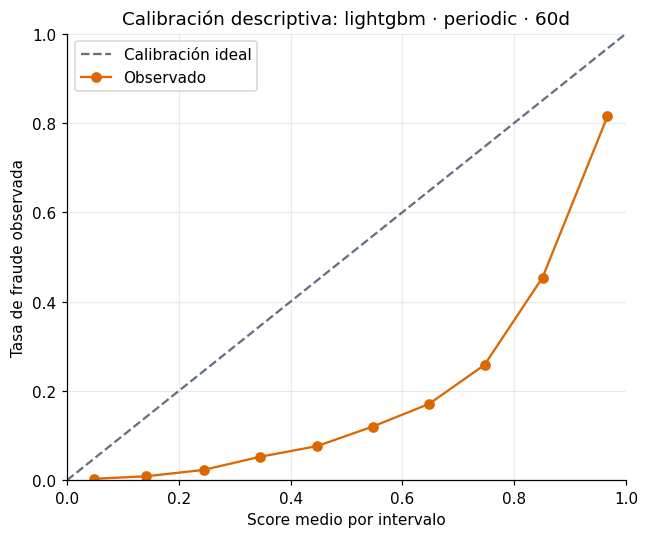

In [21]:
bins = pd.cut(selected.score, bins=np.linspace(0, 1, 11), include_lowest=True)
cal = selected.groupby(bins, observed=True).agg(
    mean_score=("score", "mean"),
    fraud_rate=("isFraud", "mean"),
    rows=("isFraud", "size"),
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "--", color="#667085", label="Calibración ideal")
ax.plot(cal.mean_score, cal.fraud_rate, "o-", color=ORANGE, label="Observado")
ax.set(
    xlabel="Score medio por intervalo",
    ylabel="Tasa de fraude observada",
    title=f"Calibración descriptiva: {top.candidate}",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

**Lectura:** PR-AUC evalúa el ordenamiento de fraudes; la calibración compara el score con la frecuencia observada. Los modelos usan pesos de clase, por lo que el score no debe interpretarse automáticamente como probabilidad calibrada. El notebook de costos decide la política final con otros criterios.


## Evaluación final en holdout

La política elegida en validación se evalúa aquí sobre el último 15 % de las transacciones. La matriz binaria usa el **umbral de escalamiento** guardado en `frozen_choice.json`: un score igual o mayor se marca como fraude. Las transacciones enviadas a revisión pero por debajo de ese umbral cuentan como predicción negativa en esta matriz; la matriz no representa por sí sola las tres acciones de la política.


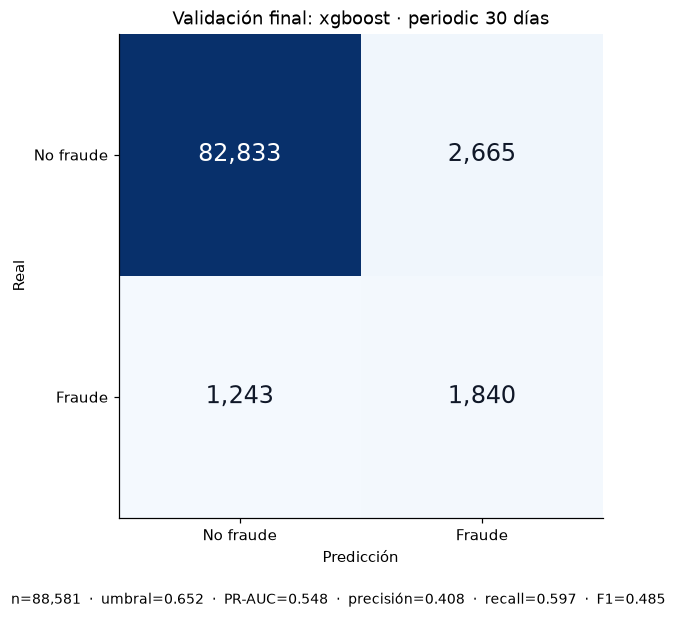

In [34]:
from sklearn.metrics import confusion_matrix, precision_score

choice = json.loads((outputs / "costos/frozen_choice.json").read_text(encoding="utf-8"))
final_metrics = json.loads(
    (outputs / "modelo_final/final_metrics.json").read_text(encoding="utf-8")
)
holdout = pd.read_csv(
    outputs / "modelo_final/holdout_predictions.csv.gz",
    usecols=["isFraud", "score"],
)
predicted_fraud = holdout.score >= choice["escalate_threshold"]
cm = confusion_matrix(holdout.isFraud, predicted_fraud, labels=[0, 1])
holdout_precision = precision_score(holdout.isFraud, predicted_fraud)
assert cm.sum() == final_metrics["rows"]
assert cm[1].sum() == final_metrics["fraud"]
assert np.isclose(cm[1, 1] / cm[1].sum(), final_metrics["recall"])

fig, ax = plt.subplots(figsize=(7, 5.6))
ax.imshow(cm, cmap="Blues", vmin=0)
for (row, col), count in np.ndenumerate(cm):
    ax.text(
        col,
        row,
        f"{count:,}",
        ha="center",
        va="center",
        fontsize=16,
        color="white" if count > cm.max() / 2 else "#101828",
    )
ax.set_xticks([0, 1], ["No fraude", "Fraude"])
ax.set_yticks([0, 1], ["No fraude", "Fraude"])
ax.set(
    xlabel="Predicción",
    ylabel="Real",
    title=f"Validación final: {choice['model']} · {choice['strategy']} {choice['window_days']} días",
)
fig.text(
    0.5,
    0.01,
    f"n={len(holdout):,}  ·  umbral={choice['escalate_threshold']:.3f}  ·  "
    f"PR-AUC={final_metrics['pr_auc']:.3f}  ·  precisión={holdout_precision:.3f}  ·  "
    f"recall={final_metrics['recall']:.3f}  ·  F1={final_metrics['f1']:.3f}",
    ha="center",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.045, 1, 1])
plt.show()

## Tabla final de métricas

AUC corresponde al área bajo la curva ROC; PR-AUC es la precisión promedio. Precisión, recall y F1 usan el umbral de escalamiento de la matriz anterior.


In [23]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

metricas_holdout = pd.DataFrame(
    {
        "Precisión": [precision_score(holdout.isFraud, predicted_fraud)],
        "Recall": [recall_score(holdout.isFraud, predicted_fraud)],
        "F1 score": [f1_score(holdout.isFraud, predicted_fraud)],
        "AUC (ROC)": [roc_auc_score(holdout.isFraud, holdout.score)],
        "PR-AUC": [average_precision_score(holdout.isFraud, holdout.score)],
    },
    index=["Holdout"],
)
assert np.isclose(metricas_holdout.loc["Holdout", "PR-AUC"], final_metrics["pr_auc"])
assert np.isclose(metricas_holdout.loc["Holdout", "F1 score"], final_metrics["f1"])
display(metricas_holdout.round(4))

,Precisión,Recall,F1 score,AUC (ROC),PR-AUC
Holdout,0.4084,0.5968,0.485,0.9085,0.5475


## Comparación de costos y política elegida en Validación

Estas figuras usan `outputs/costos/`. El ranking toma **la mejor pareja de umbrales de cada candidato** según la regla de menor arrepentimiento máximo. Los costos son estimaciones bajo cuatro escenarios, no costos observados; no incluyen cómputo ni mantenimiento del reentrenamiento. La comparación se hizo en la porción de validación con etiquetas disponibles antes del holdout.


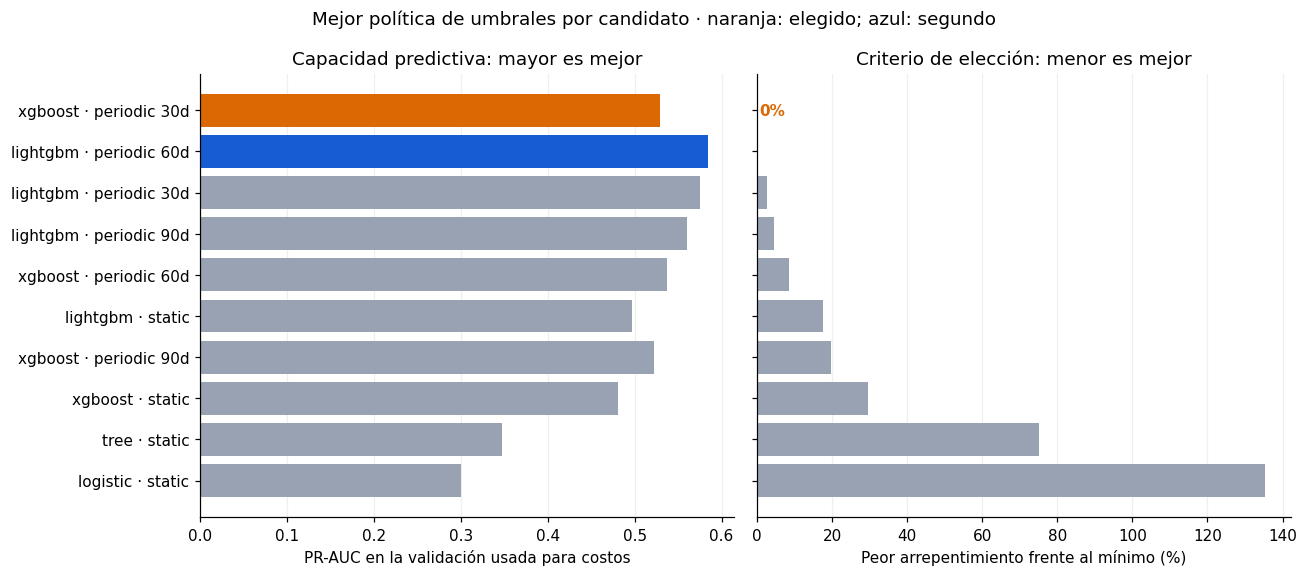

In [ ]:
ranking_costos = pd.read_csv(
    outputs / "costos/candidate_ranking.csv", dtype={"window_days": str}
)
escenarios_costos = pd.read_csv(
    outputs / "costos/validation_scenarios.csv", dtype={"window_days": str}
)
sensibilidad_cupo = pd.read_csv(outputs / "costos/capacity_sensitivity.csv")
mejores = ranking_costos.drop_duplicates(["model", "strategy", "window_days"]).copy()
mejores["candidato"] = mejores.apply(
    lambda r: f"{r.model} · {r.strategy}"
    + (f" {r.window_days}d" if r.window_days != "static" else ""),
    axis=1,
)
assert mejores.iloc[0]["model"] == choice["model"]
assert mejores.iloc[0]["window_days"] == choice["window_days"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
colors_cost = [
    ORANGE if i == 0 else BLUE if i == 1 else "#98a2b3" for i in range(len(mejores))
]
for ax, metric, label in [
    (axes[0], "validation_pr_auc", "PR-AUC en la validación usada para costos"),
    (axes[1], "worst_regret_pct", "Peor arrepentimiento frente al mínimo (%)"),
]:
    ax.barh(mejores.candidato, mejores[metric], color=colors_cost)
    ax.set_xlabel(label)
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
axes[0].invert_yaxis()
axes[0].set_title("Capacidad predictiva: mayor es mejor")
axes[1].set_title("Criterio de elección: menor es mejor")
axes[1].text(0.5, 0, "0%", va="center", color=ORANGE, fontweight="bold")
fig.suptitle(
    "Mejor política de umbrales por candidato · naranja: elegido; azul: segundo"
)
fig.tight_layout()
plt.show()

### Comparación agrupada por modelo y política

El análisis de costos evaluó static y periodic (30, 60 y 90 días); quality no tiene resultados de costos en este ranking.


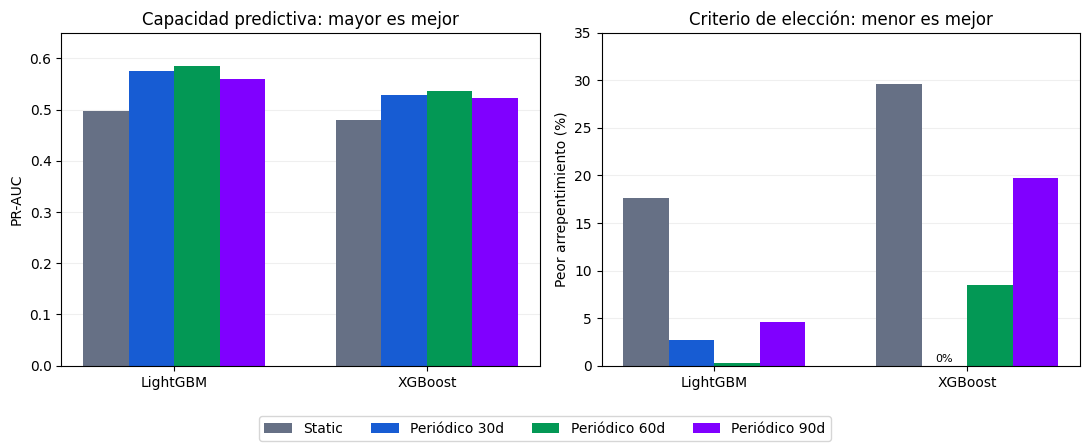

In [ ]:
cost_variants = [
    ("static", "static", "Static", "#667085"),
    ("periodic", "30", "Periódico 30d", BLUE),
    ("periodic", "60", "Periódico 60d", GREEN),
    ("periodic", "90", "Periódico 90d", "#8000ff"),
]
models_cost = ["lightgbm", "xgboost"]
x_cost = np.arange(len(models_cost))
width_cost = 0.18
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for i, (strategy, days, label, color) in enumerate(cost_variants):
    rows = mejores[
        (mejores.strategy == strategy) & (mejores.window_days == days)
    ].set_index("model")
    positions = x_cost + (i - 1.5) * width_cost
    for ax, metric in zip(axes, ["validation_pr_auc", "worst_regret_pct"]):
        bars = ax.bar(
            positions,
            rows.loc[models_cost, metric],
            width_cost,
            label=label,
            color=color,
        )
        if metric == "worst_regret_pct":
            for bar in bars:
                if bar.get_height() == 0:
                    ax.annotate(
                        "0%",
                        (bar.get_x() + bar.get_width() / 2, 0),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center",
                        fontsize=8,
                    )
for ax in axes:
    ax.set_xticks(x_cost, ["LightGBM", "XGBoost"])
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
axes[0].set(
    ylabel="PR-AUC", title="Capacidad predictiva: mayor es mejor", ylim=(0, 0.65)
)
axes[1].set(
    ylabel="Peor arrepentimiento (%)",
    title="Criterio de elección: menor es mejor",
    ylim=(0, 35),
)
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=4)
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

### Costo por escenario de los dos primeros candidatos

El segundo candidato logra mayor PR-AUC, pero el elegido tiene un costo estimado ligeramente menor en cada escenario. La segunda gráfica muestra esa diferencia; la escala del costo depende de los supuestos del proyecto.


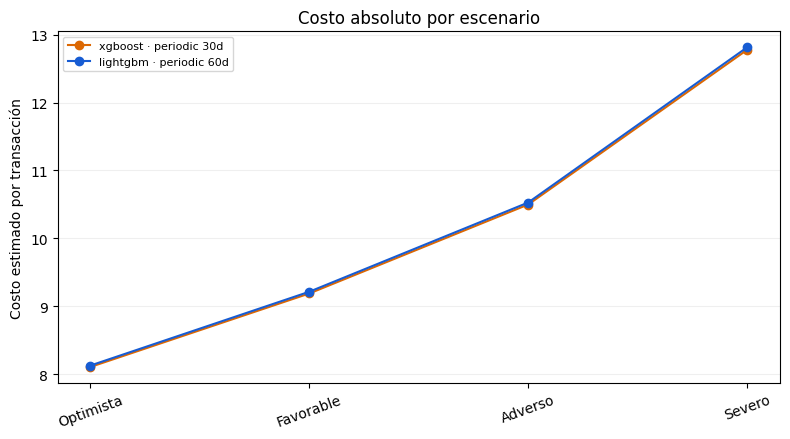

In [25]:
comparados = mejores.iloc[:2]
perfiles = []
for _, candidato in comparados.iterrows():
    filtro = (
        (escenarios_costos.model == candidato["model"])
        & (escenarios_costos.strategy == candidato["strategy"])
        & (escenarios_costos.window_days == candidato["window_days"])
        & np.isclose(escenarios_costos.review_threshold, candidato["review_threshold"])
        & np.isclose(
            escenarios_costos.escalate_threshold, candidato["escalate_threshold"]
        )
    )
    tramo = escenarios_costos.loc[filtro, ["scenario", "cost_per_txn"]].copy()
    tramo["candidato"] = candidato["candidato"]
    perfiles.append(tramo)
perfiles = pd.concat(perfiles, ignore_index=True)
orden = ["optimista_100_100", "favorable_90_98", "adverso_80_95", "severo_60_90"]
comparacion = perfiles.pivot(
    index="scenario", columns="candidato", values="cost_per_txn"
).loc[orden]
assert comparacion.notna().all().all()
primero, segundo = comparados.candidato.iloc[:2]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(orden))
ax.plot(x, comparacion[primero], "o-", color=ORANGE, label=primero)
ax.plot(x, comparacion[segundo], "o-", color=BLUE, label=segundo)
ax.set(ylabel="Costo estimado por transacción", title="Costo absoluto por escenario")
ax.set_xticks(x, ["Optimista", "Favorable", "Adverso", "Severo"], rotation=20)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

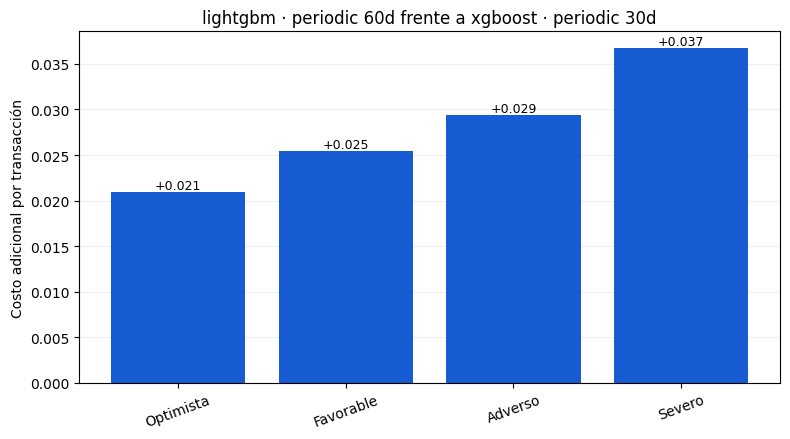

In [ ]:
diferencia = comparacion[segundo] - comparacion[primero]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(orden))
ax.bar(x, diferencia, color=BLUE)
ax.set(ylabel="Costo adicional por transacción", title=f"{segundo} frente a {primero}")
for i, valor in enumerate(diferencia):
    ax.text(i, valor, f"+{valor:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x, ["Optimista", "Favorable", "Adverso", "Severo"], rotation=20)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### Sensibilidad al cupo de revisión

Se mantiene el modelo y los umbrales elegidos; solo cambia el máximo de transacciones que se pueden revisar al día. El porcentaje se aplica a la mediana diaria histórica.


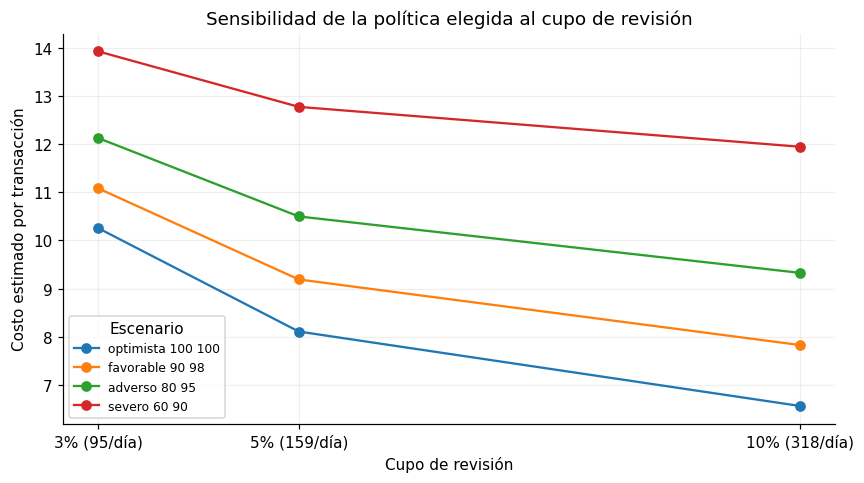

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for escenario, grupo in sensibilidad_cupo.groupby("scenario", sort=False):
    grupo = grupo.sort_values("capacity_fraction")
    ax.plot(
        grupo.capacity_fraction * 100,
        grupo.cost_per_txn,
        marker="o",
        label=escenario.replace("_", " "),
    )
capacidades = sensibilidad_cupo.drop_duplicates("capacity_fraction").sort_values(
    "capacity_fraction"
)
ax.set_xticks(
    capacidades.capacity_fraction * 100,
    [
        f"{100 * r.capacity_fraction:.0f}% ({int(r.capacity_per_day)}/día)"
        for _, r in capacidades.iterrows()
    ],
)
ax.set(
    xlabel="Cupo de revisión",
    ylabel="Costo estimado por transacción",
    title="Sensibilidad de la política elegida al cupo de revisión",
)
ax.grid(alpha=0.2)
ax.legend(title="Escenario", fontsize=8)
fig.tight_layout()
plt.show()

## Resultados y operación en el holdout final

Las figuras siguientes usan las salidas de `04_modelo_final.ipynb`. Muestran **solo la política congelada** (XGBoost periódico de 30 días) en el holdout retrospectivo; no comparan allí todos los candidatos. Los importes son costos simulados bajo los supuestos del proyecto y no incluyen el cómputo del reentrenamiento.


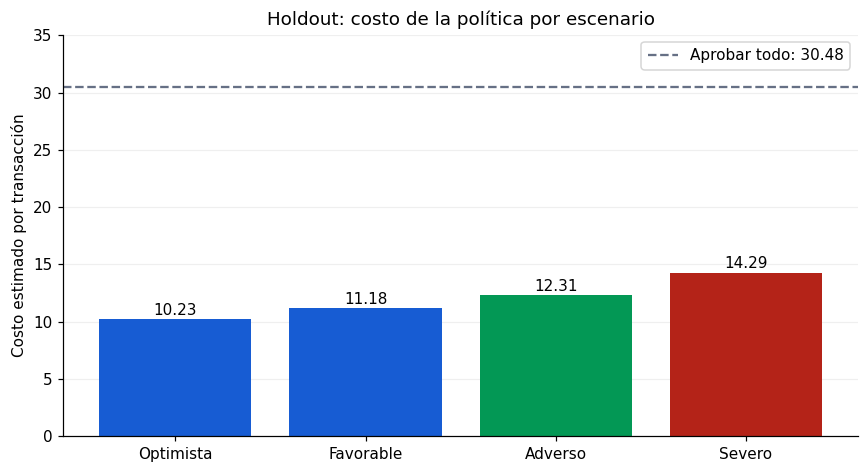

In [27]:
costos_holdout = pd.read_csv(outputs / "modelo_final/holdout_cost_scenarios.csv")
orden_escenarios = [
    "optimista_100_100",
    "favorable_90_98",
    "adverso_80_95",
    "severo_60_90",
]
costos_holdout = (
    costos_holdout.set_index("scenario").loc[orden_escenarios].reset_index()
)
base_por_transaccion = costos_holdout.approve_all_total.iloc[0] / final_metrics["rows"]
assert np.allclose(
    costos_holdout.approve_all_total, costos_holdout.approve_all_total.iloc[0]
)

fig, ax = plt.subplots(figsize=(8, 4.4))
x = np.arange(len(costos_holdout))
ax.bar(x, costos_holdout.cost_per_txn, color=[BLUE, BLUE, GREEN, RED])
ax.axhline(
    base_por_transaccion,
    color="#667085",
    ls="--",
    label=f"Aprobar todo: {base_por_transaccion:.2f}",
)
for i, valor in enumerate(costos_holdout.cost_per_txn):
    ax.text(i, valor + 0.4, f"{valor:.2f}", ha="center")
ax.set_xticks(x, ["Optimista", "Favorable", "Adverso", "Severo"])
ax.set(
    ylabel="Costo estimado por transacción",
    title="Holdout: costo de la política por escenario",
)
ax.set_ylim(0, base_por_transaccion * 1.15)
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### Qué decisión recibió cada clase

Los porcentajes se calculan **dentro de cada clase real**. La revisión es una tercera acción: no equivale automáticamente a detener un fraude. En esta simulación, su efectividad depende del escenario.


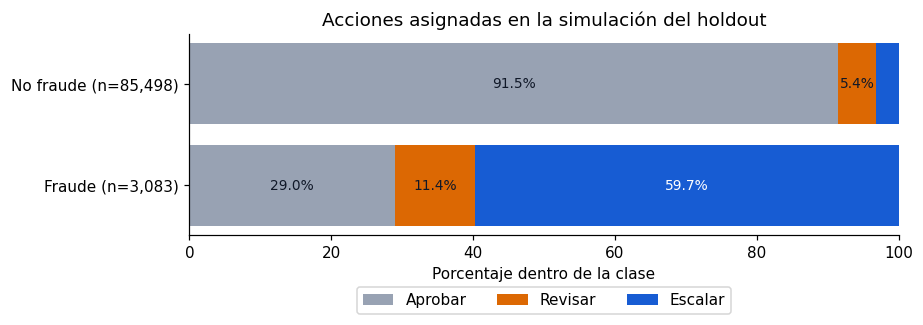

In [28]:
decisiones_holdout = pd.read_csv(
    outputs / "modelo_final/holdout_decisions.csv.gz", usecols=["isFraud", "action"]
)
acciones = ["approve", "review", "escalate"]
conteos = pd.crosstab(decisiones_holdout.isFraud, decisiones_holdout.action).reindex(
    index=[0, 1], columns=acciones, fill_value=0
)
assert conteos.to_numpy().sum() == final_metrics["rows"]
porcentajes = conteos.div(conteos.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(8.5, 3.2))
left = np.zeros(2)
for accion, nombre, color in zip(
    acciones, ["Aprobar", "Revisar", "Escalar"], ["#98a2b3", ORANGE, BLUE]
):
    values = porcentajes[accion].to_numpy()
    ax.barh([0, 1], values, left=left, label=nombre, color=color)
    for i, (offset, value) in enumerate(zip(left, values)):
        if value >= 5:
            ax.text(
                offset + value / 2,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white" if accion == "escalate" else "#101828",
                fontsize=9,
            )
    left += values
ax.set_yticks(
    [0, 1],
    [f"No fraude (n={conteos.loc[0].sum():,})", f"Fraude (n={conteos.loc[1].sum():,})"],
)
ax.invert_yaxis()
ax.set(
    xlim=(0, 100),
    xlabel="Porcentaje dentro de la clase",
    title="Acciones asignadas en la simulación del holdout",
)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.22))
fig.tight_layout()
plt.show()

### Rendimiento y volumen de cada ajuste semanal

El CSV mensual tiene 83 088 filas en el periodo 6 y solo 5 493 en el periodo 7, que es parcial; por eso se muestra el rendimiento por bloque semanal. Cada bloque del holdout recibe un modelo nuevo entrenado con una ventana reciente de 30 días y una demora de siete días en las etiquetas. La PR-AUC de cada bloque se calcula con sus propias transacciones; no debe promediarse para obtener la PR-AUC global.


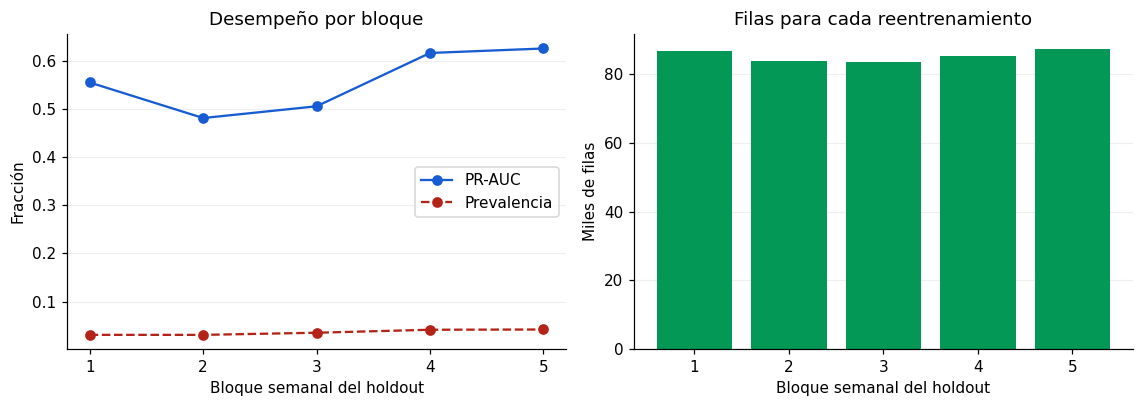

In [29]:
ajustes_finales = pd.read_csv(outputs / "modelo_final/fit_log.csv")
predicciones_semanales = pd.read_csv(
    outputs / "modelo_final/holdout_predictions.csv.gz",
    usecols=["block", "isFraud", "score"],
)
rendimiento_semanal = (
    predicciones_semanales.groupby("block")
    .apply(
        lambda grupo: pd.Series(
            {
                "rows": len(grupo),
                "pr_auc": average_precision_score(grupo.isFraud, grupo.score),
                "fraud_rate": grupo.isFraud.mean(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)
semanas = rendimiento_semanal.merge(
    ajustes_finales[["block", "train_rows"]], on="block", validate="one_to_one"
)
assert len(semanas) == len(ajustes_finales)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].plot(semanas.block + 1, semanas.pr_auc, "o-", color=BLUE, label="PR-AUC")
axes[0].plot(
    semanas.block + 1, semanas.fraud_rate, "o--", color=RED, label="Prevalencia"
)
axes[0].set(ylabel="Fracción", title="Desempeño por bloque")
axes[0].legend()
axes[1].bar(semanas.block + 1, semanas.train_rows / 1000, color=GREEN)
axes[1].set(ylabel="Miles de filas", title="Filas para cada reentrenamiento")
for ax in axes:
    ax.set_xticks(semanas.block + 1)
    ax.set_xlabel("Bloque semanal del holdout")
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### Carga diaria de la política

El cupo de 159 se llenó los 31 días del holdout. Limita **revisiones**, no escalaciones directas ni derivaciones esperadas desde revisión. Se muestra el escenario adverso (80 % de derivación desde revisión y 95 % de efectividad al escalar).


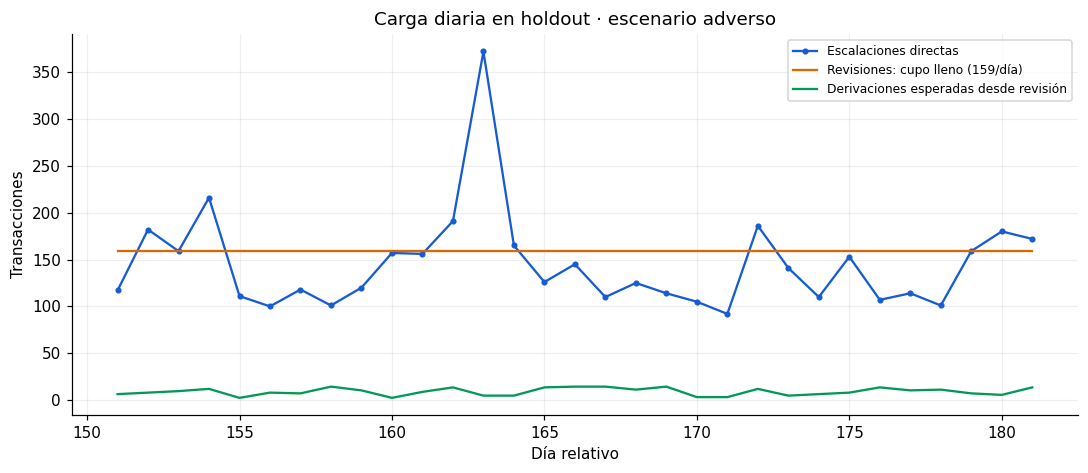

In [30]:
carga = pd.read_csv(outputs / "modelo_final/daily_workload.csv")
carga_adversa = carga[carga.scenario == "adverso_80_95"].sort_values("relative_day")
assert (carga_adversa.review_count == carga_adversa.review_capacity).all()
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(
    carga_adversa.relative_day,
    carga_adversa.direct_escalations,
    color=BLUE,
    marker=".",
    label="Escalaciones directas",
)
ax.plot(
    carga_adversa.relative_day,
    carga_adversa.review_count,
    color=ORANGE,
    label="Revisiones: cupo lleno (159/día)",
)
ax.plot(
    carga_adversa.relative_day,
    carga_adversa.expected_review_handoffs,
    color=GREEN,
    label="Derivaciones esperadas desde revisión",
)
ax.set(
    xlabel="Día relativo",
    ylabel="Transacciones",
    title="Carga diaria en holdout · escenario adverso",
)
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Segmentos de UID y control de calidad

La comparación por UID es descriptiva: no indica que la presencia de un UID conocido cause el cambio de rendimiento. El monitor de calidad es una **reproducción retrospectiva separada** de la evaluación principal; usa etiquetas maduras y solo podría activar una promoción después de dos incumplimientos consecutivos del umbral.


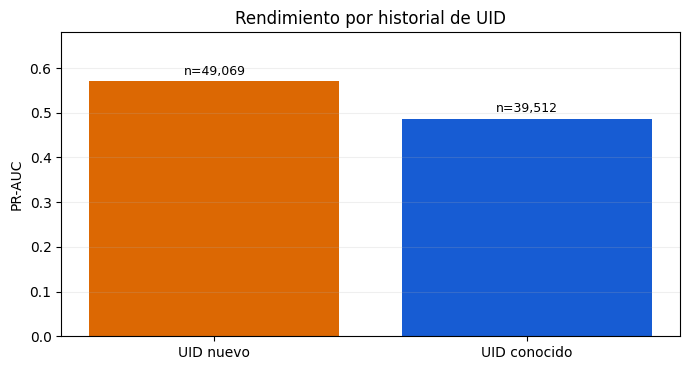

In [31]:
uid_cobertura = pd.read_csv(outputs / "modelo_final/uid_coverage.csv").sort_values(
    "uid_known_before_holdout"
)
fig, ax = plt.subplots(figsize=(7, 3.8))
labels_uid = ["UID nuevo", "UID conocido"]
ax.bar(labels_uid, uid_cobertura.pr_auc, color=[ORANGE, BLUE])
for i, row in enumerate(uid_cobertura.itertuples()):
    ax.text(i, row.pr_auc + 0.015, f"n={row.rows:,}", ha="center", fontsize=9)
ax.set(ylabel="PR-AUC", ylim=(0, 0.68), title="Rendimiento por historial de UID")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

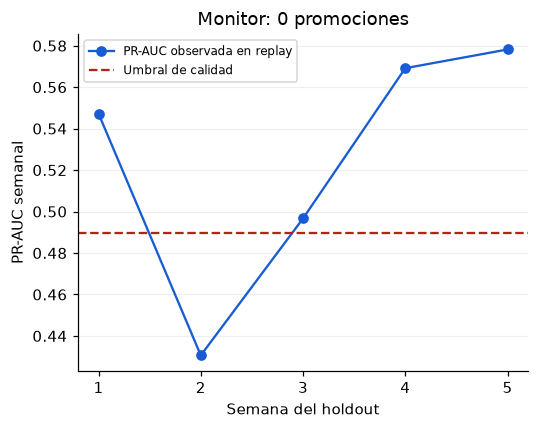

In [ ]:
ledger = pd.read_csv(outputs / "modelo_final/quality_ledger.csv")
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(
    ledger.week + 1,
    ledger.observed_pr_auc_after_action,
    "o-",
    color=BLUE,
    label="PR-AUC observada en replay",
)
ax.axhline(ledger.quality_floor.iloc[0], color=RED, ls="--", label="Umbral de calidad")
ax.set(
    xticks=ledger.week + 1,
    xlabel="Semana del holdout",
    ylabel="PR-AUC semanal",
    title=f"Monitor: {ledger.candidate_promoted.sum()} promociones",
)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()

## Tabla final de ahorro estimado

**Fórmula:** costo de aprobar todo = suma de `TransactionAmt` de los fraudes reales del holdout × 5,75; ahorro estimado = ese costo base − costo total de la política. Se muestran los cuatro supuestos de eficacia. Son unidades monetarias del importe original (su divisa no está documentada), no ahorro observado por un banco; el costo total tampoco incluye reentrenamiento.


In [32]:
importes_holdout = pd.read_csv(
    outputs / "modelo_final/holdout_decisions.csv.gz",
    usecols=["TransactionAmt", "isFraud"],
)
monto_fraudes = importes_holdout.loc[
    importes_holdout.isFraud.eq(1), "TransactionAmt"
].sum()
costo_aprobar_todo = 5.75 * monto_fraudes
assert np.allclose(costos_holdout.approve_all_total, costo_aprobar_todo)
assert np.allclose(
    costos_holdout.avoided_loss_total,
    costos_holdout.approve_all_total - costos_holdout.cost_total,
)

nombres_escenarios = {
    "optimista_100_100": "Optimista (100/100)",
    "favorable_90_98": "Favorable (90/98)",
    "adverso_80_95": "Adverso (80/95)",
    "severo_60_90": "Severo (60/90)",
}
tabla_ahorro = pd.DataFrame(
    {
        "Escenario": costos_holdout.scenario.map(nombres_escenarios),
        "Fraude total (TransactionAmt)": monto_fraudes,
        "Aprobar todo × 5,75": costo_aprobar_todo,
        "Costo total de la política": costos_holdout.cost_total,
        "Ahorro estimado": costo_aprobar_todo - costos_holdout.cost_total,
        "Reducción frente a aprobar todo (%)": 100
        * (costo_aprobar_todo - costos_holdout.cost_total)
        / costo_aprobar_todo,
    }
)
vista_ahorro = tabla_ahorro.copy()
for columna in vista_ahorro.columns[1:-1]:
    vista_ahorro[columna] = vista_ahorro[columna].map(lambda valor: f"{valor:,.2f}")
columna_pct = "Reducción frente a aprobar todo (%)"
vista_ahorro[columna_pct] = vista_ahorro[columna_pct].map(lambda valor: f"{valor:.1f}%")
display(vista_ahorro.set_index("Escenario"))

,Fraude total (TransactionAmt),"Aprobar todo × 5,75",Costo total de la política,Ahorro estimado,Reducción frente a aprobar todo (%)
Escenario,,,,,
Optimista (100/100),"469,608.52","2,700,249.00","905,946.37","1,794,302.62",66.4%
Favorable (90/98),"469,608.52","2,700,249.00","990,696.28","1,709,552.71",63.3%
Adverso (80/95),"469,608.52","2,700,249.00","1,090,642.93","1,609,606.07",59.6%
Severo (60/90),"469,608.52","2,700,249.00","1,265,431.04","1,434,817.96",53.1%
